Importing Libraries

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/dp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/dp/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/dp/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /Users/dp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

PART 1: Data Exploration, Data Cleaning & Preprocessing

In [41]:
data = pd.read_csv('amazon_co-ecommerce_sample.csv')

In [42]:
# dropping columns not useful for recommender system
dropcolumn = ['uniq_id','number_of_reviews','number_of_answered_questions','customer_questions_and_answers','sellers','description','customer_reviews']
data = data.drop(columns=dropcolumn)
data.head()

,product_name,manufacturer,price,number_available_in_stock,average_review_rating,amazon_category_and_sub_category,customers_who_bought_this_item_also_bought,product_information,product_description,items_customers_buy_after_viewing_this_item
0,Hornby 2014 Catalogue,Hornby,£3.42,5 new,4.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,http://www.amazon.co.uk/Hornby-R8150-Catalogue...,Technical Details Item Weight640 g Product Dim...,Product Description Hornby 2014 Catalogue Box ...,http://www.amazon.co.uk/Hornby-R8150-Catalogue...
1,FunkyBuys® Large Christmas Holiday Express Fes...,FunkyBuys,£16.99,NaN,4.5 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,http://www.amazon.co.uk/Christmas-Holiday-Expr...,Technical Details Manufacturer recommended age...,Size Name:Large FunkyBuys® Large Christmas Hol...,http://www.amazon.co.uk/Christmas-Holiday-Expr...
2,CLASSIC TOY TRAIN SET TRACK CARRIAGES LIGHT EN...,ccf,£9.99,2 new,3.9 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,http://www.amazon.co.uk/Classic-Train-Lights-B...,Technical Details Manufacturer recommended age...,BIG CLASSIC TOY TRAIN SET TRACK CARRIAGE LIGHT...,http://www.amazon.co.uk/Train-With-Tracks-Batt...
3,HORNBY Coach R4410A BR Hawksworth Corridor 3rd,Hornby,£39.99,NaN,5.0 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,NaN,Technical Details Item Weight259 g Product Dim...,Hornby 00 Gauge BR Hawksworth 3rd Class W 2107...,NaN
4,Hornby 00 Gauge 0-4-0 Gildenlow Salt Co. Steam...,Hornby,£32.19,NaN,4.7 out of 5 stars,Hobbies > Model Trains & Railway Sets > Rail V...,http://www.amazon.co.uk/Hornby-R6367-RailRoad-...,Technical Details Item Weight159 g Product Dim...,Product Description Hornby RailRoad 0-4-0 Gild...,http://www.amazon.co.uk/Hornby-R2672-RailRoad-...


1. Numerical features

In [43]:
# pre-process the numerical columns
# price
data['price']= data['price'].astype(str).str.replace('£','').str.strip()
# Some prices include a range, so we impute the average of the range:
for idx, value in data['price'].items():
    if "-" in str(value):
        value_range = [float(match) for match in re.findall(r'\d+\.\d+', value)]
        average_value = sum(value_range) / len(value_range)
        data.loc[idx, 'price'] = average_value
        
#number available in stock
data['number_available_in_stock']= data['number_available_in_stock'].astype(str).str.replace('new','').str.strip()
data['number_available_in_stock'] = data['number_available_in_stock'].astype(str).str.replace('used','').str.strip()
data['number_available_in_stock'] = data['number_available_in_stock'].astype(str).str.replace('collectible','').str.strip()
data['number_available_in_stock'] = data['number_available_in_stock'].astype(str).str.replace('refurbished','').str.strip()

#average review rating
data['average_review_rating']= data['average_review_rating'].astype(str).str.replace('out of 5 stars','').str.strip()

In [44]:
# Changing the data type of numeric columns to numeric 
numeric_columns = ['price','number_available_in_stock','average_review_rating'] 
data[numeric_columns] = data[numeric_columns].apply(pd.to_numeric, errors='coerce')
# For the remaining numeric columns, we can do a simple imputation with mode value:
numeric_columns_to_impute=['price','average_review_rating']
for column_name in numeric_columns_to_impute:
    median = data[column_name].median()
    data[column_name] = data[column_name].fillna(median)

data['number_available_in_stock'] = data['number_available_in_stock'].fillna(0)

2. Categorical Features

In [45]:
# Amazon category and sub category
data['category'] = data['amazon_category_and_sub_category'].str.split('>').str[0]
data['category'] = data['category'].fillna(data.mode()['category'])
data = data.drop(columns=['amazon_category_and_sub_category'])
# manufacturer
data['manufacturer'] = data['manufacturer'].fillna(data.mode()['manufacturer'])

# Label encoding
le_category = LabelEncoder()
le_manufacturer = LabelEncoder()
data['category'] = le_category.fit_transform(data['category'])
data['manufacturer'] = le_manufacturer.fit_transform(data['manufacturer'])

3. Text Features

In [46]:
#customer who bought this item also bought, #product information, #product description, #items customers buy after viewing this item

In [47]:
stemmer = PorterStemmer()

def process_text(text):
    # Convert to lowercase
    text = text.lower()
    # Strip special chars
    text = re.sub(r"[^a-zA-Z0-9]+", ' ', text)
    # Tokenize
    token_words = word_tokenize(text)
    # Strip stop words
    stripped_words = [word for word in token_words if word not in stopwords.words('english')]
    # Stem
    stemmed_text = [stemmer.stem(word) for word in stripped_words]
    # Join and return
    return " ".join(stemmed_text)

In [48]:
raw_text_columns = [ 'product_information', 'product_description']
data = data.dropna(subset=raw_text_columns)

# Process our text data
data['raw_text'] = data[raw_text_columns].agg(' '.join, axis=1)
data['raw_text'] = data['raw_text'].apply(process_text)
data = data.drop(columns=raw_text_columns)

In [49]:
# Preprocessing the columns to make them more readable
data['customers_who_bought_this_item_also_bought'].dropna(inplace = True)
data['items_customers_buy_after_viewing_this_item'].dropna(inplace = True )

prefix_to_remove = 'http://www.amazon.co.uk/'
suffix_to_remove = r'dp|/|[0-9A-Z]{10}'


#Converting to string
data['customers_who_bought_this_item_also_bought'] = data['customers_who_bought_this_item_also_bought'].astype(str)
data['items_customers_buy_after_viewing_this_item'] = data['items_customers_buy_after_viewing_this_item'].astype(str)


#Removing prefix
data['customers_who_bought_this_item_also_bought' ] = [data.replace(prefix_to_remove, '') for data in data['customers_who_bought_this_item_also_bought' ]]
data['items_customers_buy_after_viewing_this_item' ] = [data.replace(prefix_to_remove, '') for data in data['items_customers_buy_after_viewing_this_item' ]]


#Removing suffix
data['items_customers_buy_after_viewing_this_item'] = data['items_customers_buy_after_viewing_this_item'].str.replace(suffix_to_remove, '', regex=True)
data['customers_who_bought_this_item_also_bought'] = data['customers_who_bought_this_item_also_bought'].str.replace(suffix_to_remove, '', regex=True)


#Replacing Dash
data['customers_who_bought_this_item_also_bought' ] = [data.replace('-', ' ') for data in data['customers_who_bought_this_item_also_bought' ]]
data['items_customers_buy_after_viewing_this_item' ] = [data.replace('-', ' ') for data in data['items_customers_buy_after_viewing_this_item' ]]

#Splitting the data for each item bought
data['customers_who_bought_this_item_also_bought'] = data['customers_who_bought_this_item_also_bought'].str.split('|')
data['items_customers_buy_after_viewing_this_item'] = data['items_customers_buy_after_viewing_this_item'].str.split('|')

#explode the lists to create new rows
data = data.explode('customers_who_bought_this_item_also_bought')
data = data.explode('items_customers_buy_after_viewing_this_item')

In [50]:
# Reset the index after preprocessing to ensure consecutive indices
data.reset_index(drop=True, inplace=True)

data = data.drop(data[data['customers_who_bought_this_item_also_bought'].str.contains('nan')].index)
data = data.drop(data[data['items_customers_buy_after_viewing_this_item'].str.contains('nan')].index)

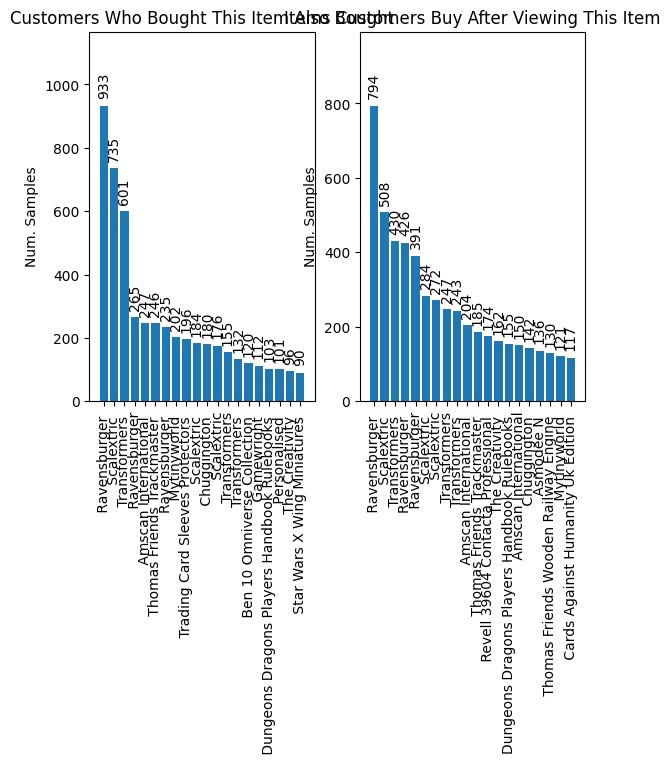

In [51]:
#Plotting the top 20 features
categorical_features = ['customers_who_bought_this_item_also_bought', 'items_customers_buy_after_viewing_this_item']


figure, axes = plt.subplots(1, 2)


axes = axes.flatten()


for idx, column in enumerate(categorical_features):

    value_counts = data[column].value_counts().nlargest(20)


    bars = axes[idx].bar(value_counts.keys(), value_counts.values)

    axes[idx].bar_label(bars, rotation=90, padding=5)
    axes[idx].set_ylabel('Num. Samples')
    axes[idx].set_title(column.title().replace("_", " "))

    formatted_keys = [category_name.title() for category_name in value_counts.keys()]
    axes[idx].set_xticks(value_counts.keys(), formatted_keys, rotation=90)


    axes[idx].set_ylim(0, max(value_counts.values) * 1.25)


plt.show()

In [52]:
#Since the two columns are so similar dropping the 'items customer buy after viewing this item' and analyzing further with the 'customer who bought this item also bought' column
value_count_items = 20
top_features = data['customers_who_bought_this_item_also_bought'].value_counts().nlargest(value_count_items).index
amazon_data_processed = data[data['customers_who_bought_this_item_also_bought'].isin(top_features)]

PART 2: Building the recommender system

In [53]:
# Prepare df_x and df_y as per your code
df_x = data.drop(['customers_who_bought_this_item_also_bought', 'items_customers_buy_after_viewing_this_item'], axis=1)
df_y = data['customers_who_bought_this_item_also_bought']

1. ITEM TO ITEM (SimpleRNN)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1630 - loss: 2.9575 - val_accuracy: 0.3802 - val_loss: 2.7430
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.4184 - loss: 2.5563 - val_accuracy: 0.4694 - val_loss: 1.8880
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5136 - loss: 1.6541 - val_accuracy: 0.6883 - val_loss: 1.3286
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.6968 - loss: 1.1821 - val_accuracy: 0.7494 - val_loss: 0.9664
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.7462 - loss: 0.8595 - val_accuracy: 0.7946 - val_loss: 0.7673
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - accuracy: 0.7841 - loss: 0.6878 - val_accuracy: 0.8007 - val_loss: 0.6718
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.7907 - loss: 0.6117 - val_accuracy: 0.7995 - val_loss: 0.6253
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.7927 - loss: 0.5613 - va

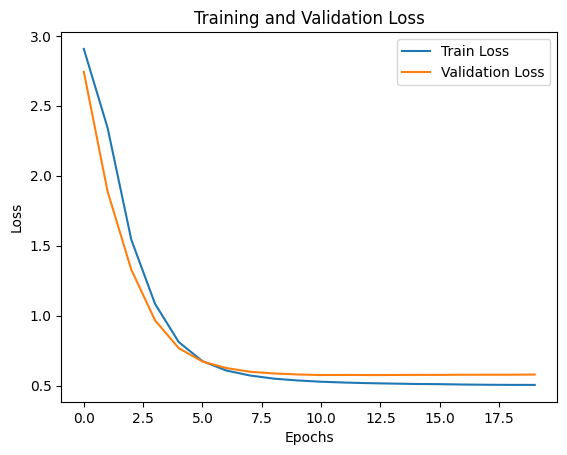

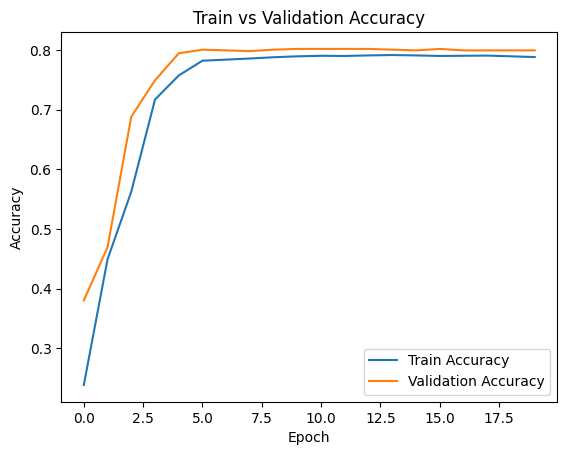

In [57]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


# Encode item
item_encoder = LabelEncoder()
df_x['item'] = item_encoder.fit_transform(df_x['product_name'])

# Encode target variable
label_encoder = LabelEncoder()
df_y_encoded = label_encoder.fit_transform(df_y)
num_classes = len(label_encoder.classes_)  # Fix for value_count_items

# Split data
dev_df_x, test_df_x, dev_df_y, test_df_y = train_test_split(df_x, df_y_encoded, test_size=0.2, random_state=42)
train_df_x, val_df_x, train_df_y, val_df_y = train_test_split(dev_df_x, dev_df_y, test_size=0.2, random_state=42)

# One-hot encode target
train_df_y_one_hot = to_categorical(train_df_y, num_classes=num_classes)
val_df_y_one_hot = to_categorical(val_df_y, num_classes=num_classes)
test_df_y_one_hot = to_categorical(test_df_y, num_classes=num_classes)


# Build model
model = Sequential()
model.add(Embedding(input_dim=len(item_encoder.classes_), output_dim=32, input_length=1))
model.add(SimpleRNN(32, activation='relu'))
model.add(Dense(units=num_classes, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_df_x['item'].values.reshape(-1, 1),
    train_df_y_one_hot,
    epochs=20,
    batch_size=32,
    validation_data=(val_df_x['item'].values.reshape(-1, 1), val_df_y_one_hot)
)

# Evaluate model
test_loss, test_acc = model.evaluate(test_df_x['item'].values.reshape(-1, 1), test_df_y_one_hot)
print(f'Test accuracy: {test_acc}')

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.show()

2. DESCRIPTION TO ITEM (LSTM)

Number of unique labels: 20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.1910 - loss: 2.6629 - val_accuracy: 0.5061 - val_loss: 1.5237
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 51s 319ms/step - accuracy: 0.5499 - loss: 1.4175 - val_accuracy: 0.6357 - val_loss: 1.0617
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 48s 302ms/step - accuracy: 0.6539 - loss: 0.9735 - val_accuracy: 0.6968 - val_loss: 0.8657
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 313ms/step - accuracy: 0.7132 - loss: 0.8303 - val_accuracy: 0.7237 - val_loss: 0.8182
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 313ms/step - accuracy: 0.7403 - loss: 0.7323 - val_accuracy: 0.7335 - val_loss: 0.7757
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 313ms/step - accuracy: 0.7544 - loss: 0.6761 - val_accuracy: 0.7213 - val_loss: 0.8132
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 311ms/step - accuracy: 0.7702 - loss: 0.6450 - val_accuracy: 0.7237 - val_loss: 0.7831
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 50s 312ms/step - accuracy: 0.7713 - loss: 0

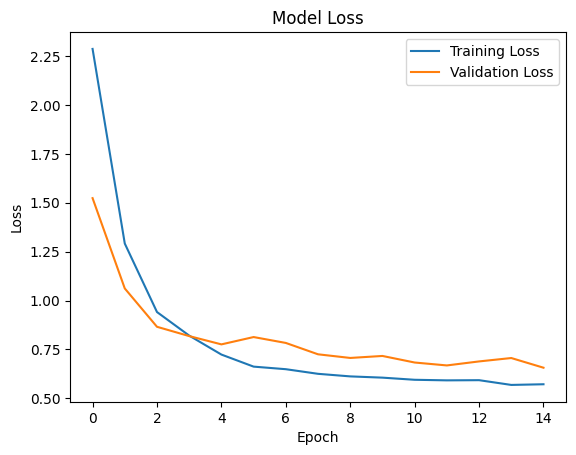

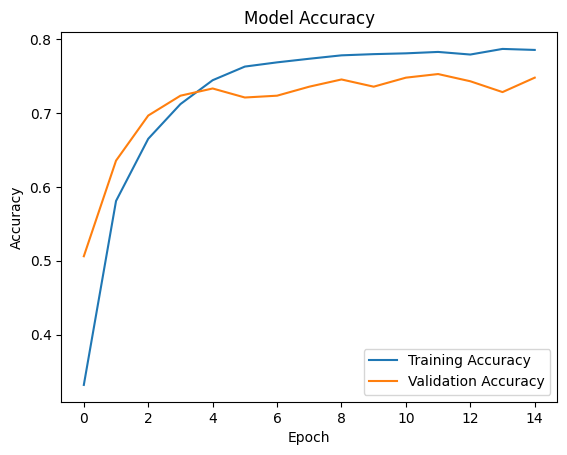

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Select top 20 classes
top_n = 20
value_counts = df_y.value_counts()
top_items = value_counts.head(top_n).index
df = pd.concat([df_x, df_y], axis=1)
df = df[df['customers_who_bought_this_item_also_bought'].isin(top_items)]
df_x = df.drop(['customers_who_bought_this_item_also_bought'], axis=1)
df_y = df['customers_who_bought_this_item_also_bought']

num_classes = value_count_items
# Preprocess text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_x['raw_text'])
sequences = tokenizer.texts_to_sequences(df_x['raw_text'])
X = pad_sequences(sequences)
vocab_size = len(tokenizer.word_index) + 1

# Encode Y
label_encoder = LabelEncoder()
df_y_encoded = label_encoder.fit_transform(df_y)

# Verify number of unique labels
print(f"Number of unique labels: {len(set(df_y_encoded))}")
assert len(set(df_y_encoded)) <= num_classes, "Number of unique labels exceeds num_classes"

y_categorical = to_categorical(df_y_encoded, num_classes=num_classes)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=X.shape[1]))
model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(25, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=15, batch_size=23, validation_split=0.1)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()